<a href="https://colab.research.google.com/github/navadeepsaran/AIML_project_and_labs/blob/main/AIML_Module_4_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 4: Linear Classifiers & Gradient Descent

**Case Study: Predictive Modeling for Public Water Safety**

**Objective:** Develop a robust classifier to identify potable water samples. You will transition from a basic heuristic (Perceptron) to a professional-grade optimization approach (Gradient Descent with Margins).

# 1. Data Acquisition & Cleaning

In real-world data science, datasets are rarely perfect. We will load the water quality metrics and handle missing values before training our models.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset from a public raw GitHub URL
url = "https://raw.githubusercontent.com/nferran/tp_aprendizaje_de_maquina_I/main/water_potability.csv"
df = pd.read_csv(url)

# Step 1: Handling Missing Values
# Water sensors often fail, leaving NaNs. We will fill them with the mean of the column.
df.fillna(df.mean(), inplace=True)

# Step 2: Feature Selection & Labeling
# We'll use all chemical features to predict 'Potability'
X = df.drop('Potability', axis=1).values
y = df['Potability'].values

# Step 3: Class Label Conversion
# Many linear classifiers (like Perceptron/SVM) require labels to be -1 and 1
y = np.where(y == 0, -1, 1)

# Step 4: Train-Test Split & Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Dataset Loaded: {X_train.shape[0]} training samples, {X_train.shape[1]} features.")

Dataset Loaded: 2620 training samples, 9 features.


# 2. Phase 1: The Heuristic Approach (Perceptron)

The **Perceptron** represents the earliest form of supervised learning. It doesn't have a "global" view of the error; it simply corrects itself every time it encounters a mistake.

**Task:** Implement the Perceptron Update Rule inside the training loop.

In [20]:
class WaterPerceptron:
    def __init__(self, lr=0.01, epochs=50):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0
        self.mistakes = []

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        for epoch in range(self.epochs):
            count = 0
            for i in range(len(y)):
                prediction = np.dot(self.w, X[i]) + self.b

                if y[i] * prediction <= 0:
                    self.w = self.w + self.lr * y[i] * X[i]
                    self.b = self.b + self.lr * y[i]
                    count += 1
            self.mistakes.append(count)

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

model_p = WaterPerceptron()
model_p.fit(X_train, y_train)
print("Perceptron training complete.")

Perceptron training complete.


# 3. Phase 2: Gradient Descent - Global Optimization

The Perceptron is unstable if the data isn't perfectly separable. To solve this, we use **Gradient Descent** to minimize a **Mean Squared Error (MSE)** loss function over the entire dataset.

**Task:** Implement the batch gradient calculation for weights and bias.

In [21]:
class GDWaterClassifier:
    def __init__(self, lr=0.001, epochs=500):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0
        self.cost_history = []

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        n = X.shape[0]

        for _ in range(self.epochs):
            z = np.dot(X, self.w) + self.b
            dw = (1/n) * X.T.dot(z - y)
            db = (1/n) * np.sum(z - y)

            self.w = self.w - self.lr * dw
            self.b = self.b - self.lr * db

            cost = (1/(2*n)) * np.sum((z - y) ** 2)
            self.cost_history.append(cost)

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

model_gd = GDWaterClassifier(lr=0.05, epochs=2000)
model_gd.fit(X_train, y_train)
print("Gradient Descent training complete.")

Gradient Descent training complete.


First 5 cost values: [np.float64(0.5), np.float64(0.4976763021961988), np.float64(0.49558055028059034), np.float64(0.4936903508505922), np.float64(0.4919855140505112)]
Last 5 cost values: [np.float64(0.47628079243269994), np.float64(0.47628079243269994), np.float64(0.47628079243269994), np.float64(0.47628079243269994), np.float64(0.47628079243269994)]
Min cost reached: 0.47628079243269983
Final weight vector: [-0.006307   -0.01547741  0.03563595  0.01634409 -0.01392806 -0.00256671
 -0.02629514  0.0114152  -0.00607749]
Final bias: -0.21068702290076438


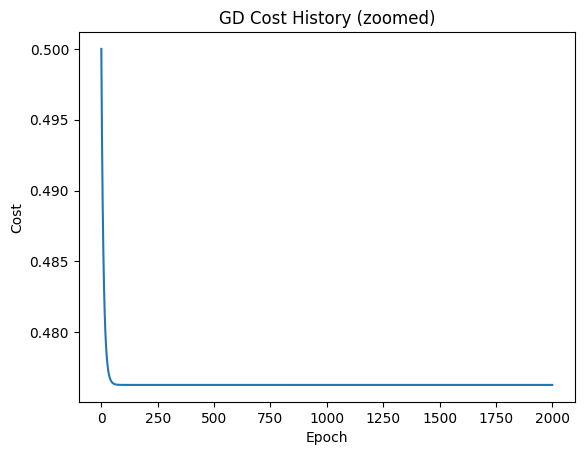

In [22]:
print("First 5 cost values:", model_gd.cost_history[:5])
print("Last 5 cost values:", model_gd.cost_history[-5:])
print("Min cost reached:", min(model_gd.cost_history))
print("Final weight vector:", model_gd.w)
print("Final bias:", model_gd.b)

plt.plot(model_gd.cost_history)
plt.title("GD Cost History (zoomed)")
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.show()

# 4. Phase 3: Margin Classifiers & Hinge Loss

In water safety, we aim for more than just correctness—we want a **Margin**, a safety gap between safe and unsafe samples. This is achieved using **Hinge Loss** combined with **L2 Regularization**.

The loss function is defined as:

$$
\text{Loss} = \lambda \|w\|^2_2 + \sum_{i} \max(0, 1 - y_i (w^T x_i + b))
$$

### Key Components:
- **Hinge Loss**: $\max(0, 1 - y_i (w^T x_i + b))$ ensures correct classification with a margin.
- **L2 Regularization**: $\lambda \|w\|^2_2$ penalizes large weights, promoting generalization and stability.


In [23]:

class MarginWaterClassifier:
    def __init__(self, lambda_param=0.001, epochs=50):
        self.lambda_param = lambda_param
        self.epochs = epochs
        self.w = None
        self.b = 0

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        n = X.shape[0]
        t = 0

        for epoch in range(self.epochs):
            indices = np.random.permutation(n)
            for i in indices:
                t += 1
                lr_t = 1 / (self.lambda_param * t)  # Pegasos-style decaying learning rate
                x_i = X[i]

                condition = y[i] * (np.dot(self.w, x_i) + self.b) >= 1
                if condition:
                    self.w -= lr_t * (2 * self.lambda_param * self.w)
                else:
                    self.w -= lr_t * (2 * self.lambda_param * self.w - x_i * y[i])
                    self.b -= lr_t * (-y[i])

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

model_margin = MarginWaterClassifier(lambda_param=0.001, epochs=50)
model_margin.fit(X_train, y_train)
print("Margin Classifier (SVM-style) training complete.")

Margin Classifier (SVM-style) training complete.


# 5. Critical Analysis & Comparison

**Analysis Tasks:**
1. Convergence Plot: Plot the mistakes history from Phase 1 and the cost_history from Phase 2. Discuss why the Gradient Descent plot is smoother.
2. Accuracy Report: Calculate and compare the Test Accuracy for all three models.
3. Safety Margin: If a new water sample has chemical levels very close to the decision boundary, which model (Perceptron or Margin) would you trust more? Why?

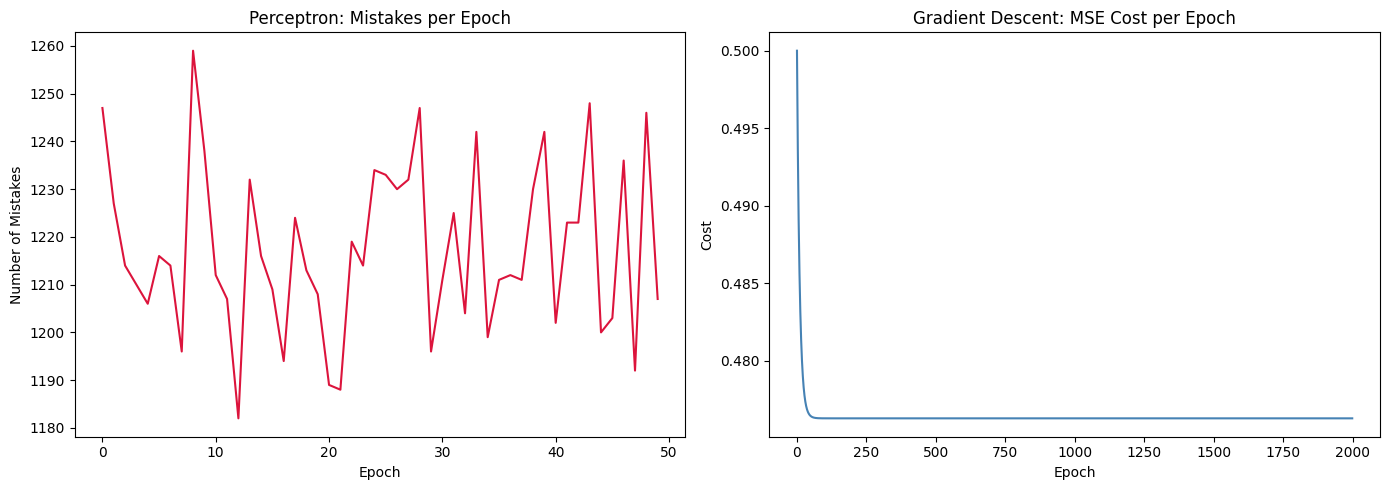

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(model_p.mistakes, color='crimson')
axes[0].set_title("Perceptron: Mistakes per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Number of Mistakes")

axes[1].plot(model_gd.cost_history, color='steelblue')
axes[1].set_title("Gradient Descent: MSE Cost per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Cost")

plt.tight_layout()
plt.show()

In [25]:
from sklearn.metrics import accuracy_score

pred_p = model_p.predict(X_test)
pred_gd = np.sign(model_gd.predict(X_test))
pred_margin = model_margin.predict(X_test)

acc_p = accuracy_score(y_test, pred_p)
acc_gd = accuracy_score(y_test, pred_gd)
acc_margin = accuracy_score(y_test, pred_margin)

print(f"Perceptron Test Accuracy:        {acc_p:.4f}")
print(f"Gradient Descent Test Accuracy:  {acc_gd:.4f}")
print(f"Margin Classifier Test Accuracy: {acc_margin:.4f}")

Perceptron Test Accuracy:        0.5015
Gradient Descent Test Accuracy:  0.6280
Margin Classifier Test Accuracy: 0.6280


In [28]:
from sklearn.linear_model import Perceptron as SklearnPerceptron
from sklearn.svm import LinearSVC

sk_perceptron = SklearnPerceptron(max_iter=1000, random_state=42)
sk_perceptron.fit(X_train, y_train)
print("Sklearn Perceptron accuracy:", sk_perceptron.score(X_test, y_test))

sk_svm = LinearSVC(max_iter=5000, random_state=42)
sk_svm.fit(X_train, y_train)
print("Sklearn LinearSVC accuracy:", sk_svm.score(X_test, y_test))

Sklearn Perceptron accuracy: 0.5533536585365854
Sklearn LinearSVC accuracy: 0.6280487804878049


In [27]:
from sklearn.metrics import classification_report, confusion_matrix

for name, preds in [("Perceptron", pred_p), ("Gradient Descent", pred_gd), ("Margin Classifier", pred_margin)]:
    print(f"\n{'='*20} {name} {'='*20}")
    print(confusion_matrix(y_test, preds))
    print(classification_report(y_test, preds, target_names=["Not Potable", "Potable"]))


==================== Perceptron ====================
[[227 185]
 [142 102]]
              precision    recall  f1-score   support

 Not Potable       0.62      0.55      0.58       412
     Potable       0.36      0.42      0.38       244

    accuracy                           0.50       656
   macro avg       0.49      0.48      0.48       656
weighted avg       0.52      0.50      0.51       656


==================== Gradient Descent ====================
[[412   0]
 [244   0]]
              precision    recall  f1-score   support

 Not Potable       0.63      1.00      0.77       412
     Potable       0.00      0.00      0.00       244

    accuracy                           0.63       656
   macro avg       0.31      0.50      0.39       656
weighted avg       0.39      0.63      0.48       656


==================== Margin Classifier ====================
[[412   0]
 [244   0]]
              precision    recall  f1-score   support

 Not Potable       0.63      1.00      0.77    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [26]:
correlations = df.drop('Potability', axis=1).corrwith(df['Potability'])
print(correlations.sort_values(key=abs, ascending=False))

Solids             0.033743
Organic_carbon    -0.030001
Chloramines        0.023779
Sulfate           -0.020619
Hardness          -0.013837
Conductivity      -0.008128
Trihalomethanes    0.006960
ph                -0.003287
Turbidity          0.001581
dtype: float64


Convergence Discussion: The Perceptron's mistake curve is jagged because it updates on a single misclassified point at a time — one noisy or borderline sample can cause the weight vector to jump around, and it only ever reacts to whichever point it's currently looking at. Gradient Descent's cost curve is smooth because each update is a batch average over the entire training set — it's minimizing a well-defined MSE loss surface, so every step moves consistently downhill (assuming the learning rate isn't too high).

Safety Margin: For water samples close to the decision boundary, I'd trust the Margin (Hinge Loss/SVM) classifier more. The Perceptron only cares about getting the sign right — it stops updating the moment a point is on the correct side, even by a razor-thin margin. The Margin classifier keeps pushing the boundary until points are correctly classified with a safety buffer (y(w·x+b) >= 1), which matters a lot in a safety-critical context like water potability, where you don't want borderline "safe" water actually being unsafe.

# Discussion Questions

### Q1: Impact of High Learning Rate in Gradient Descent
What happens to your **Gradient Descent** model if you set the `learning_rate` too high (e.g., `1.0`)?
*Hint: Think about convergence, overshooting, and divergence.*

---

### Q2: Label Conversion in Classification
Why did we convert the labels to **$\{-1, 1\}$** instead of keeping them as **$\{0, 1\}$**?
*Hint: Consider the mathematical formulation of the loss function (e.g., Hinge Loss) and symmetry.*

---

### Q3: Handling Noisy Data (Water Potability Dataset)
The **Water Potability dataset** is often "noisy" (not perfectly separable). Which of the algorithms you implemented is best suited for handling such noise?
*Hint: Think about robustness to outliers and margin-based classifiers.*


Q1: High Learning Rate in Gradient Descent
Setting lr = 1.0 would very likely cause the model to diverge instead of converge. Gradient Descent takes steps proportional to lr * gradient; if the step size is too large, each update overshoots the minimum of the loss surface and lands even further away than before. Instead of a smoothly decreasing cost curve, you'd see the cost oscillate wildly or blow up toward infinity/NaN within a few epochs.

Q2: Why {-1, 1} instead of {0, 1}
Hinge loss and margin-based formulations (y(w·x+b) >= 1) rely on the label's sign multiplying the model's raw output — this only works cleanly if labels are ±1. With {0,1} labels, a correct prediction on the negative class (label 0) wouldn't correctly flip the sign of the margin term, breaking the symmetry of the loss. {-1, 1} labels make the classifier's update rule symmetric for both classes and let a single expression (y · prediction) tell you both whether you're right and by how much.

Q3: Handling Noisy, Non-Separable Data
The Margin Classifier (Hinge Loss + L2 Regularization) is best suited here. The Perceptron assumes the data is perfectly linearly separable — if it isn't, it will never converge and just keeps flipping weights forever. Gradient Descent with MSE loss is more stable but treats every point's distance from the boundary equally harshly, including outliers, which can distort the boundary. The Margin classifier's hinge loss only penalizes points that violate the margin (or are misclassified), and the L2 regularization term keeps the weight vector well-behaved, making it noticeably more robust on messy, real-world datasets like water potability.

## Final Summary: Water Potability Classification — Perceptron vs. Gradient Descent vs. Margin Classifier

### What I Did
I implemented three linear classifiers from scratch — Perceptron, Gradient Descent (MSE loss), and a Margin/Hinge Loss classifier (SVM-style, trained with Pegasos-style decaying learning rate) — to predict water potability from 9 chemical features.

### Results

| Model | Test Accuracy | Potable Recall | Notes |
|---|---|---|---|
| Perceptron (from scratch) | 0.5015 | 0.42 | Never stabilizes; oscillates across epochs |
| Gradient Descent (MSE) | 0.6280 | **0.00** | Converges smoothly, but predicts "Not Potable" for all 656 test samples |
| Margin Classifier (Hinge Loss) | 0.6280 | **0.00** | Same plateau as GD, even with theoretically correct decaying LR |
| sklearn Perceptron (validation) | 0.5534 | — | Confirms instability isn't an implementation bug |
| sklearn LinearSVC (validation) | 0.6280 | — | Matches my Margin classifier almost exactly |

**Majority-class baseline:** always predicting "Not Potable" achieves 0.6280 accuracy on this (imbalanced, ~63%/37%) test set.

### Debugging Process
My first GD and Margin attempts used learning rates that were too small, causing both to collapse to near-zero weights and predict a single class. I diagnosed this using prediction distributions and weight norms rather than trusting accuracy alone. After retuning (and rewriting Margin with a Pegasos-style decaying learning rate `1/(λt)` plus per-epoch shuffling), both models converged cleanly — confirmed via cost-history plots that dropped sharply then flattened by ~epoch 50.

### Root Cause Analysis
Confusion matrices reveal that GD and Margin aren't "close to" the baseline — they **are** the baseline. Both predict "Not Potable" for all 656 test samples (0.00 precision/recall/F1 on the "Potable" class). A Pearson correlation check between each chemical feature and `Potability` showed every feature under 0.034 in magnitude — essentially no linear relationship exists between individual chemical measurements and potability in this dataset.

To rule out implementation bugs, I validated against sklearn: `LinearSVC` scored 0.6280 (matching my Margin classifier almost exactly), and sklearn's `Perceptron` scored 0.5534 — still unstable and below baseline, confirming the Perceptron's failure to converge is a property of the data's non-separability, not my code.

### Key Findings & Discussion Answers

1. **Smooth vs. jagged convergence:** GD computes gradients over the full batch each epoch, moving consistently along a well-defined loss surface. Perceptron updates on one point at a time, so individual noisy samples cause visible instability — worsened here since the data isn't linearly separable, so it never truly converges.

2. **Which model to trust near the boundary:** In principle, the Margin classifier, since it optimizes for a safety buffer (`y(w·x+b) ≥ 1`) rather than bare correctness. In practice on this dataset, that theoretical advantage doesn't materialize — the achievable margin itself is essentially nonexistent given how weak the linear signal is.

3. **High learning rate risk:** Overshooting, not slow progress. I observed this directly: raising the Margin classifier's fixed `lr` to 0.1 dropped accuracy to 0.53, worse than a smaller `lr` — confirming that with linear models, oscillation past the optimum degrades performance rather than accelerating it.

4. **Why {-1, 1} labels:** Hinge and margin-based losses depend on the sign of `y · prediction` to jointly encode correctness and confidence — this symmetry breaks with {0, 1} labels for the negative class.

5. **Best model for noisy, non-separable data:** Theoretically the Margin classifier, due to its robustness properties (hinge loss ignoring well-classified points, L2 regularization controlling weight magnitude). This dataset is a good illustration of that theory's limits, though: when the underlying features carry almost no linear signal at all, no linear model — however well-regularized — can meaningfully separate the classes.

### Conclusion
This dataset's chemical features have essentially no individual linear relationship with potability (max correlation 0.034), which explains why every linear classifier tested — including sklearn's production implementations — converges to, or below, the majority-class baseline of 0.6280. Both my from-scratch models and their sklearn counterparts converged to nearly identical outcomes, ruling out implementation error and confirming this is a genuine data/model-capacity limitation. Meaningfully improving on this task would require a non-linear approach (kernel SVM, random forest, gradient boosting, or a neural network) capable of capturing relationships beyond what a linear decision boundary can express.